# Judge Evaluation Results - Interactive Analysis

This notebook provides interactive analysis and visualization of judge evaluation results.

## Features:
- Load and explore evaluation results
- Identify mismatches between resolved status and judge outcomes
- Visualize distributions and patterns
- Export filtered subsets for further investigation

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from IPython.display import display, Markdown

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Evaluation Results

Specify the path to your evaluation results file.

In [3]:
# Path to evaluation results
RESULTS_PATH = "judge_evaluation_results_20260203_074104/evaluation_results.jsonl"

# Load results
results = []
with open(RESULTS_PATH, 'r') as f:
    for line in f:
        results.append(json.loads(line))

print(f"Loaded {len(results)} evaluation results")

Loaded 100 evaluation results


## 2. Convert to DataFrame

Create a structured DataFrame for easier analysis.

In [4]:
def parse_results_to_df(results):
    """Convert results to a flat DataFrame"""
    rows = []
    
    for result in results:
        instance_id = result.get('instance_id')
        resolved = result.get('resolved')
        
        if 'error' in result:
            rows.append({
                'instance_id': instance_id,
                'resolved': resolved,
                'has_error': True,
                'error_type': result.get('error'),
                'outcome_status': None,
                'alignment_score': None,
                'failure_class': None,
            })
            continue
        
        judge_eval = result.get('judge_evaluation', {})
        outcome = judge_eval.get('outcome', {})
        patch_alignment = judge_eval.get('patch_alignment', {})
        primary_failure = judge_eval.get('primary_failure', {})
        quality_scores = judge_eval.get('quality_scores', {})
        
        row = {
            'instance_id': instance_id,
            'resolved': resolved,
            'has_error': False,
            'error_type': None,
            
            # Outcome
            'outcome_status': outcome.get('status'),
            'final_test_state': outcome.get('final_test_state'),
            
            # Alignment
            'alignment_score': patch_alignment.get('alignment_score'),
            'accidental_pass_risk': patch_alignment.get('accidental_pass_risk'),
            'num_missing_requirements': len(patch_alignment.get('missing_requirements', [])),
            'num_extra_behaviors': len(patch_alignment.get('extra_behavior_changes', [])),
            
            # Primary failure
            'failure_class': primary_failure.get('class'),
            'failure_inferability': primary_failure.get('inferability'),
            'failure_reason_code': primary_failure.get('reason_code'),
            'failure_stage': primary_failure.get('stage'),
            
            # Quality scores
            'spec_alignment': quality_scores.get('spec_alignment'),
            'repo_exploration': quality_scores.get('repo_exploration'),
            'root_cause_quality': quality_scores.get('root_cause_quality'),
            'patch_correctness': quality_scores.get('patch_correctness'),
            'validation_rigor': quality_scores.get('validation_rigor'),
            'iteration_efficiency': quality_scores.get('iteration_efficiency'),
        }
        
        rows.append(row)
    
    return pd.DataFrame(rows)

df = parse_results_to_df(results)

# Reset index for clean filtering
df = df.reset_index(drop=True)

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Show first few rows
display(df.head())

DataFrame shape: (100, 20)
Columns: ['instance_id', 'resolved', 'has_error', 'error_type', 'outcome_status', 'final_test_state', 'alignment_score', 'accidental_pass_risk', 'num_missing_requirements', 'num_extra_behaviors', 'failure_class', 'failure_inferability', 'failure_reason_code', 'failure_stage', 'spec_alignment', 'repo_exploration', 'root_cause_quality', 'patch_correctness', 'validation_rigor', 'iteration_efficiency']


,instance_id,resolved,has_error,error_type,outcome_status,final_test_state,alignment_score,accidental_pass_risk,num_missing_requirements,num_extra_behaviors,failure_class,failure_inferability,failure_reason_code,failure_stage,spec_alignment,repo_exploration,root_cause_quality,patch_correctness,validation_rigor,iteration_efficiency
0,astropy__astropy-12907,False,False,None,inconclusive,not_run,0.0,unknown,3.0,1.0,internal,inferable_from_golden,INT_FIX_LOCATION_WRONG,implementation,0.0,1.0,0.0,0.0,0.0,1.0
1,astropy__astropy-13236,False,False,None,wrong_fix,not_run,0.0,low,3.0,1.0,internal,inferable_from_golden,INT_FIX_LOCATION_WRONG,implementation,0.0,2.0,0.0,0.0,0.0,1.0
2,astropy__astropy-14309,False,False,None,true_pass,all_green,4.0,low,0.0,0.0,none,na,NONE,finalization,4.0,4.0,4.0,4.0,4.0,4.0
3,astropy__astropy-14369,False,False,None,wrong_fix,not_run,1.0,high,2.0,2.0,internal,inferable_from_golden,INT_RCA_WRONG,implementation,1.0,3.0,1.0,1.0,1.0,1.0
4,astropy__astropy-14995,False,False,None,true_pass,not_run,4.0,low,0.0,0.0,none,na,NONE,finalization,4.0,4.0,4.0,4.0,3.0,4.0


## 3. Basic Statistics

In [5]:
# Filter out errors for analysis
valid_df = df[~df['has_error']].copy()
valid_df = valid_df.reset_index(drop=True)

print(f"Total instances: {len(df)}")
print(f"Valid evaluations: {len(valid_df)}")
print(f"Errors: {df['has_error'].sum()}")
print()
print(f"Resolved: {(valid_df['resolved'] == True).sum()}")
print(f"Unresolved: {(valid_df['resolved'] == False).sum()}")
print()
print("Outcome distribution:")
print(valid_df['outcome_status'].value_counts())

Total instances: 100
Valid evaluations: 98
Errors: 2

Resolved: 35
Unresolved: 63

Outcome distribution:
outcome_status
true_pass       66
wrong_fix       22
inconclusive     5
partial_fix      5
Name: count, dtype: int64


## 4. Find Mismatches: Resolved but Wrong Fix

**These are instances that passed the test suite (resolved=True) but the judge identified them as wrong fixes.**

This is important because it reveals:
- Potential test suite gaps
- Overfitting or accidental passes
- Cases where the agent found a different (incorrect) solution that happens to pass tests

In [6]:
# Resolved but wrong fix
resolved_but_wrong = valid_df[
    (valid_df['resolved'] == True) & 
    (valid_df['outcome_status'] == 'wrong_fix')
].copy()

print(f"\n{'='*80}")
print(f"RESOLVED (passed tests) but WRONG FIX (by judge)")
print(f"{'='*80}")
print(f"\nFound {len(resolved_but_wrong)} instances")
print(f"This represents {100*len(resolved_but_wrong)/len(valid_df[valid_df['resolved']==True]):.1f}% of resolved instances")

if len(resolved_but_wrong) > 0:
    print("\nInstance IDs:")
    for idx, row in resolved_but_wrong.iterrows():
        print(f"  {row['instance_id']}")
        print(f"    - Alignment score: {row['alignment_score']}/4")
        print(f"    - Failure class: {row['failure_class']}")
        print(f"    - Reason: {row['failure_reason_code']}")
        print(f"    - Accidental pass risk: {row['accidental_pass_risk']}")
    
    # Save to CSV for further investigation
    output_file = "resolved_but_wrong_fix.csv"
    resolved_but_wrong.to_csv(output_file, index=False)
    print(f"\n✓ Saved to {output_file}")
else:
    print("\n✓ No mismatches found!")


RESOLVED (passed tests) but WRONG FIX (by judge)

Found 2 instances
This represents 5.7% of resolved instances

Instance IDs:
  django__django-11999
    - Alignment score: 1.0/4
    - Failure class: internal
    - Reason: INT_FIX_STRATEGY_WRONG_LEVEL
    - Accidental pass risk: low
  django__django-12155
    - Alignment score: 1.0/4
    - Failure class: internal
    - Reason: INT_IMPL_LOGIC_BUG
    - Accidental pass risk: low

✓ Saved to resolved_but_wrong_fix.csv


## 5. Find Mismatches: Unresolved but True Pass

**These are instances that failed the test suite (resolved=False) but the judge evaluated them as correct.**

This could indicate:
- Test suite issues (flaky tests, environment problems)
- Incomplete test coverage in golden tests
- Timing or race condition issues

In [7]:
# Unresolved but true pass
unresolved_but_correct = valid_df[
    (valid_df['resolved'] == False) & 
    (valid_df['outcome_status'] == 'true_pass')
].copy()

print(f"\n{'='*80}")
print(f"UNRESOLVED (failed tests) but TRUE PASS (by judge)")
print(f"{'='*80}")
print(f"\nFound {len(unresolved_but_correct)} instances")
print(f"This represents {100*len(unresolved_but_correct)/len(valid_df[valid_df['resolved']==False]):.1f}% of unresolved instances")

if len(unresolved_but_correct) > 0:
    print("\nInstance IDs:")
    for idx, row in unresolved_but_correct.iterrows():
        print(f"  {row['instance_id']}")
        print(f"    - Alignment score: {row['alignment_score']}/4")
        print(f"    - Patch correctness: {row['patch_correctness']}/4")
        print(f"    - Final test state: {row['final_test_state']}")
    
    # Save to CSV for further investigation
    output_file = "unresolved_but_true_pass.csv"
    unresolved_but_correct.to_csv(output_file, index=False)
    print(f"\n✓ Saved to {output_file}")
else:
    print("\n✓ No mismatches found!")


UNRESOLVED (failed tests) but TRUE PASS (by judge)

Found 34 instances
This represents 54.0% of unresolved instances

Instance IDs:
  astropy__astropy-14309
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: all_green
  astropy__astropy-14995
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: not_run
  astropy__astropy-7606
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: all_green
  django__django-11333
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: all_green
  django__django-12276
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: not_run
  django__django-12304
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: all_green
  django__django-12406
    - Alignment score: 4.0/4
    - Patch correctness: 4.0/4
    - Final test state: all_green
  django__django-13023
    - Alignment score: 4

## 6. Mismatch Summary

In [8]:
# Create confusion matrix
confusion_data = []

for resolved_val in [True, False]:
    for outcome in ['true_pass', 'wrong_fix', 'partial_fix', 'inconclusive']:
        count = len(valid_df[
            (valid_df['resolved'] == resolved_val) & 
            (valid_df['outcome_status'] == outcome)
        ])
        confusion_data.append({
            'Resolved (Test Suite)': 'Yes' if resolved_val else 'No',
            'Judge Outcome': outcome,
            'Count': count
        })

confusion_df = pd.DataFrame(confusion_data)
confusion_pivot = confusion_df.pivot(index='Resolved (Test Suite)', columns='Judge Outcome', values='Count')

print("\n" + "="*80)
print("CONFUSION MATRIX: Test Suite Result vs Judge Evaluation")
print("="*80)
display(confusion_pivot.fillna(0).astype(int))

# Highlight mismatches
print("\n" + "="*80)
print("MISMATCH SUMMARY")
print("="*80)
print(f"\nResolved=Yes + wrong_fix: {len(resolved_but_wrong)} instances (FALSE POSITIVES)")
print(f"Resolved=No + true_pass: {len(unresolved_but_correct)} instances (FALSE NEGATIVES)")
print(f"\nTotal mismatches: {len(resolved_but_wrong) + len(unresolved_but_correct)} / {len(valid_df)} ({100*(len(resolved_but_wrong) + len(unresolved_but_correct))/len(valid_df):.1f}%)")


CONFUSION MATRIX: Test Suite Result vs Judge Evaluation


Judge Outcome,inconclusive,partial_fix,true_pass,wrong_fix
Resolved (Test Suite),,,,
No,5,4,34,20
Yes,0,1,32,2



MISMATCH SUMMARY

Resolved=Yes + wrong_fix: 2 instances (FALSE POSITIVES)
Resolved=No + true_pass: 34 instances (FALSE NEGATIVES)

Total mismatches: 36 / 98 (36.7%)


## 7. Visualizations

### 7.1 Outcome Distribution by Resolved Status

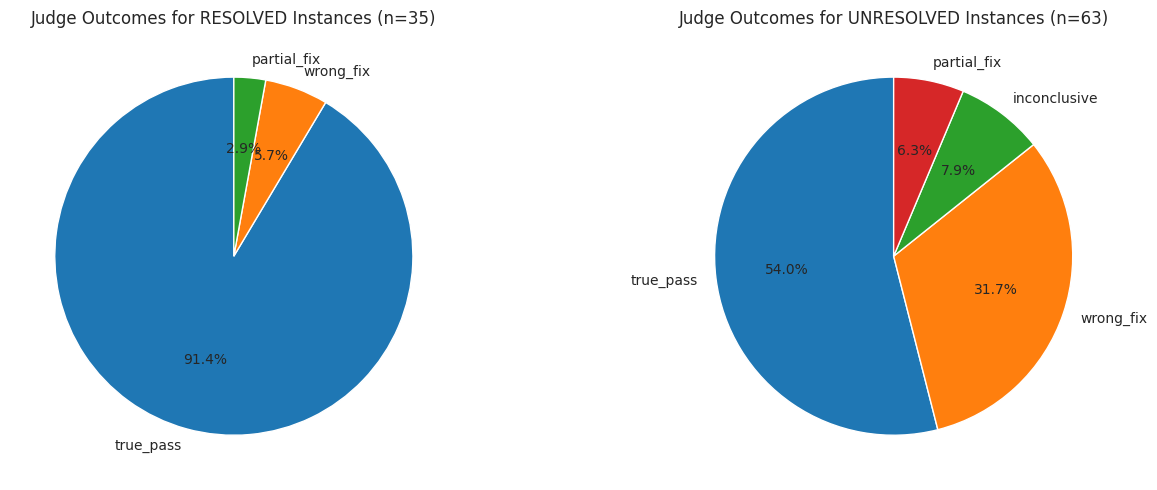

✓ Saved to outcome_distribution_by_resolved.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resolved instances
resolved_outcomes = valid_df[valid_df['resolved'] == True]['outcome_status'].value_counts()
axes[0].pie(resolved_outcomes.values, labels=resolved_outcomes.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Judge Outcomes for RESOLVED Instances (n={len(valid_df[valid_df["resolved"]==True])})')

# Unresolved instances
unresolved_outcomes = valid_df[valid_df['resolved'] == False]['outcome_status'].value_counts()
axes[1].pie(unresolved_outcomes.values, labels=unresolved_outcomes.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Judge Outcomes for UNRESOLVED Instances (n={len(valid_df[valid_df["resolved"]==False])})')

plt.tight_layout()
plt.savefig('outcome_distribution_by_resolved.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to outcome_distribution_by_resolved.png")

### 7.2 Alignment Score Distribution

/tmp/ipykernel_337828/1639066238.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=['Resolved', 'Unresolved'])


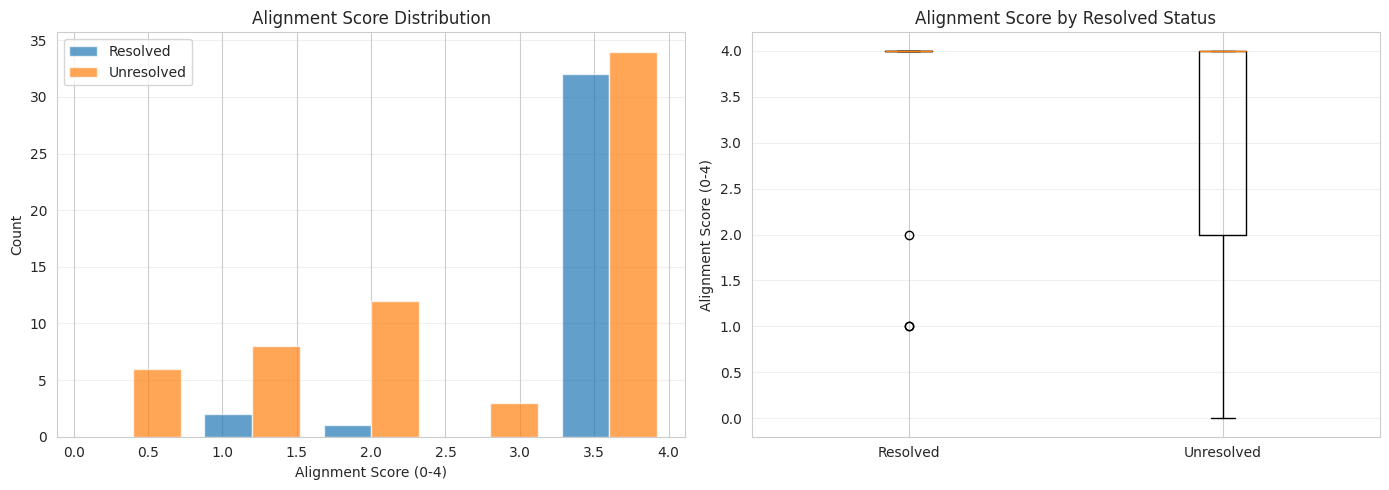

Resolved - Mean: 3.77, Median: 4.00
Unresolved - Mean: 2.81, Median: 4.00

✓ Saved to alignment_score_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by resolved status
resolved_scores = valid_df[valid_df['resolved'] == True]['alignment_score'].dropna()
unresolved_scores = valid_df[valid_df['resolved'] == False]['alignment_score'].dropna()

axes[0].hist([resolved_scores, unresolved_scores], bins=5, label=['Resolved', 'Unresolved'], alpha=0.7)
axes[0].set_xlabel('Alignment Score (0-4)')
axes[0].set_ylabel('Count')
axes[0].set_title('Alignment Score Distribution')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot
data_for_box = [
    resolved_scores.tolist(),
    unresolved_scores.tolist()
]
axes[1].boxplot(data_for_box, labels=['Resolved', 'Unresolved'])
axes[1].set_ylabel('Alignment Score (0-4)')
axes[1].set_title('Alignment Score by Resolved Status')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('alignment_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Resolved - Mean: {resolved_scores.mean():.2f}, Median: {resolved_scores.median():.2f}")
print(f"Unresolved - Mean: {unresolved_scores.mean():.2f}, Median: {unresolved_scores.median():.2f}")
print("\n✓ Saved to alignment_score_distribution.png")

### 7.3 Quality Scores Comparison

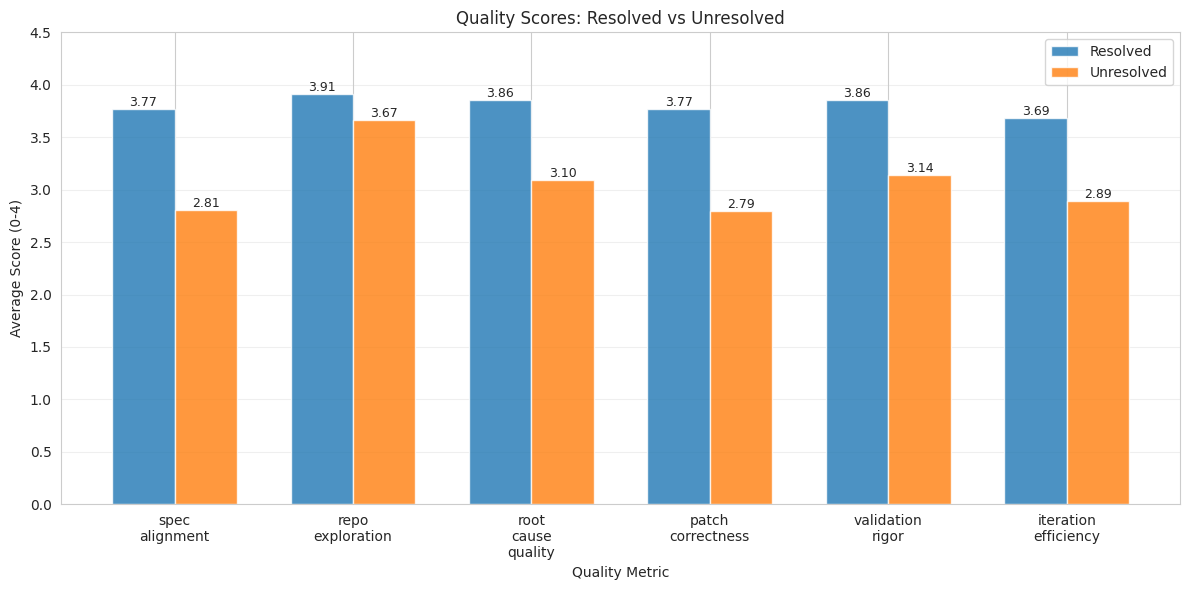

✓ Saved to quality_scores_comparison.png


In [11]:
quality_metrics = [
    'spec_alignment', 'repo_exploration', 'root_cause_quality',
    'patch_correctness', 'validation_rigor', 'iteration_efficiency'
]

resolved_quality = valid_df[valid_df['resolved'] == True][quality_metrics].mean()
unresolved_quality = valid_df[valid_df['resolved'] == False][quality_metrics].mean()

# Create grouped bar chart
x = np.arange(len(quality_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, resolved_quality, width, label='Resolved', alpha=0.8)
bars2 = ax.bar(x + width/2, unresolved_quality, width, label='Unresolved', alpha=0.8)

ax.set_xlabel('Quality Metric')
ax.set_ylabel('Average Score (0-4)')
ax.set_title('Quality Scores: Resolved vs Unresolved')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', '\n') for m in quality_metrics], rotation=0)
ax.legend()
ax.set_ylim(0, 4.5)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('quality_scores_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to quality_scores_comparison.png")

### 7.4 Failure Class Distribution

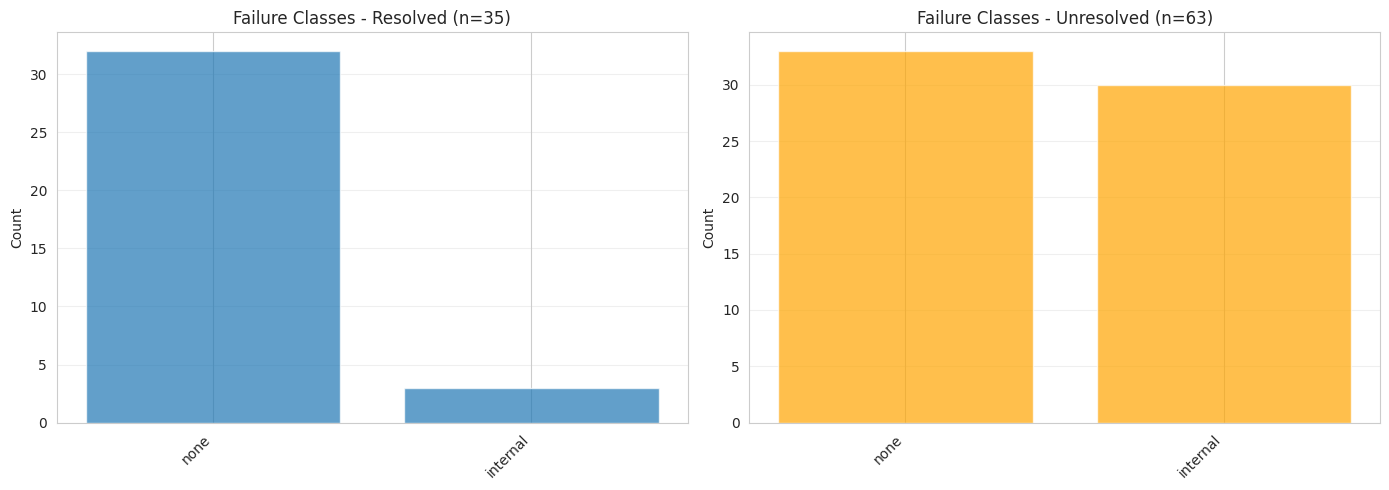

✓ Saved to failure_class_distribution.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Resolved
resolved_failures = valid_df[valid_df['resolved'] == True]['failure_class'].value_counts()
axes[0].bar(range(len(resolved_failures)), resolved_failures.values, alpha=0.7)
axes[0].set_xticks(range(len(resolved_failures)))
axes[0].set_xticklabels(resolved_failures.index, rotation=45, ha='right')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Failure Classes - Resolved (n={len(valid_df[valid_df["resolved"]==True])})')
axes[0].grid(axis='y', alpha=0.3)

# Unresolved
unresolved_failures = valid_df[valid_df['resolved'] == False]['failure_class'].value_counts()
axes[1].bar(range(len(unresolved_failures)), unresolved_failures.values, alpha=0.7, color='orange')
axes[1].set_xticks(range(len(unresolved_failures)))
axes[1].set_xticklabels(unresolved_failures.index, rotation=45, ha='right')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Failure Classes - Unresolved (n={len(valid_df[valid_df["resolved"]==False])})')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('failure_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to failure_class_distribution.png")

### 7.5 Accidental Pass Risk Analysis

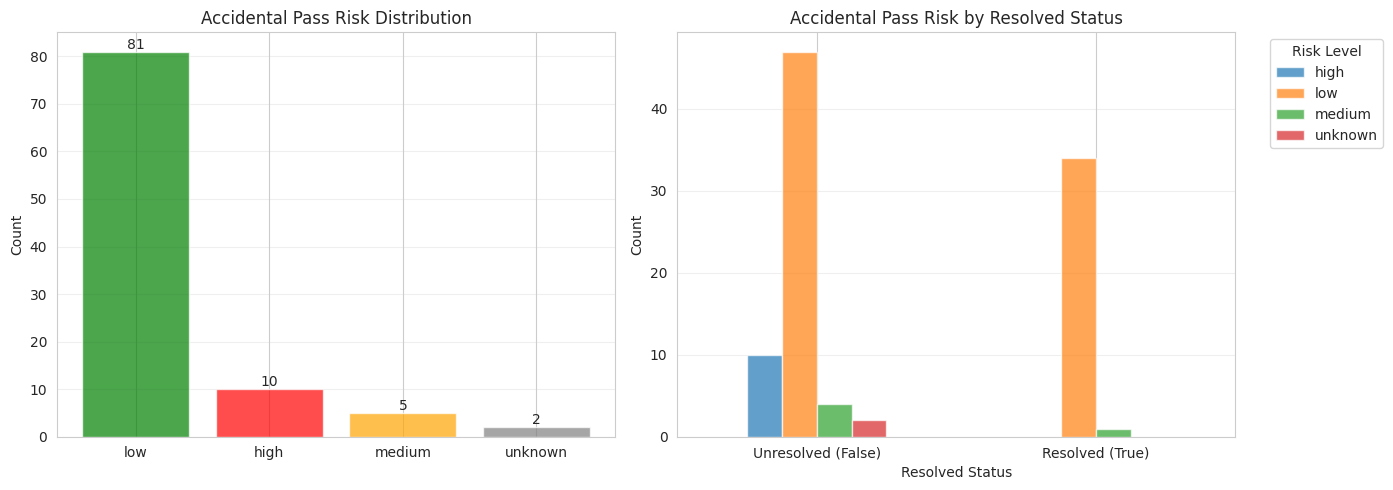

✓ Saved to accidental_pass_risk.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
risk_counts = valid_df['accidental_pass_risk'].value_counts()
colors = {'low': 'green', 'medium': 'orange', 'high': 'red', 'unknown': 'gray'}
bar_colors = [colors.get(risk, 'blue') for risk in risk_counts.index]

axes[0].bar(range(len(risk_counts)), risk_counts.values, color=bar_colors, alpha=0.7)
axes[0].set_xticks(range(len(risk_counts)))
axes[0].set_xticklabels(risk_counts.index)
axes[0].set_ylabel('Count')
axes[0].set_title('Accidental Pass Risk Distribution')
axes[0].grid(axis='y', alpha=0.3)

# Add counts on bars
for i, (risk, count) in enumerate(risk_counts.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom')

# Risk by resolved status
risk_by_resolved = pd.crosstab(valid_df['resolved'], valid_df['accidental_pass_risk'])
risk_by_resolved.plot(kind='bar', ax=axes[1], alpha=0.7, rot=0)
axes[1].set_xlabel('Resolved Status')
axes[1].set_ylabel('Count')
axes[1].set_title('Accidental Pass Risk by Resolved Status')
axes[1].set_xticklabels(['Unresolved (False)', 'Resolved (True)'])
axes[1].legend(title='Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('accidental_pass_risk.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to accidental_pass_risk.png")

### 7.6 Correlation Heatmap

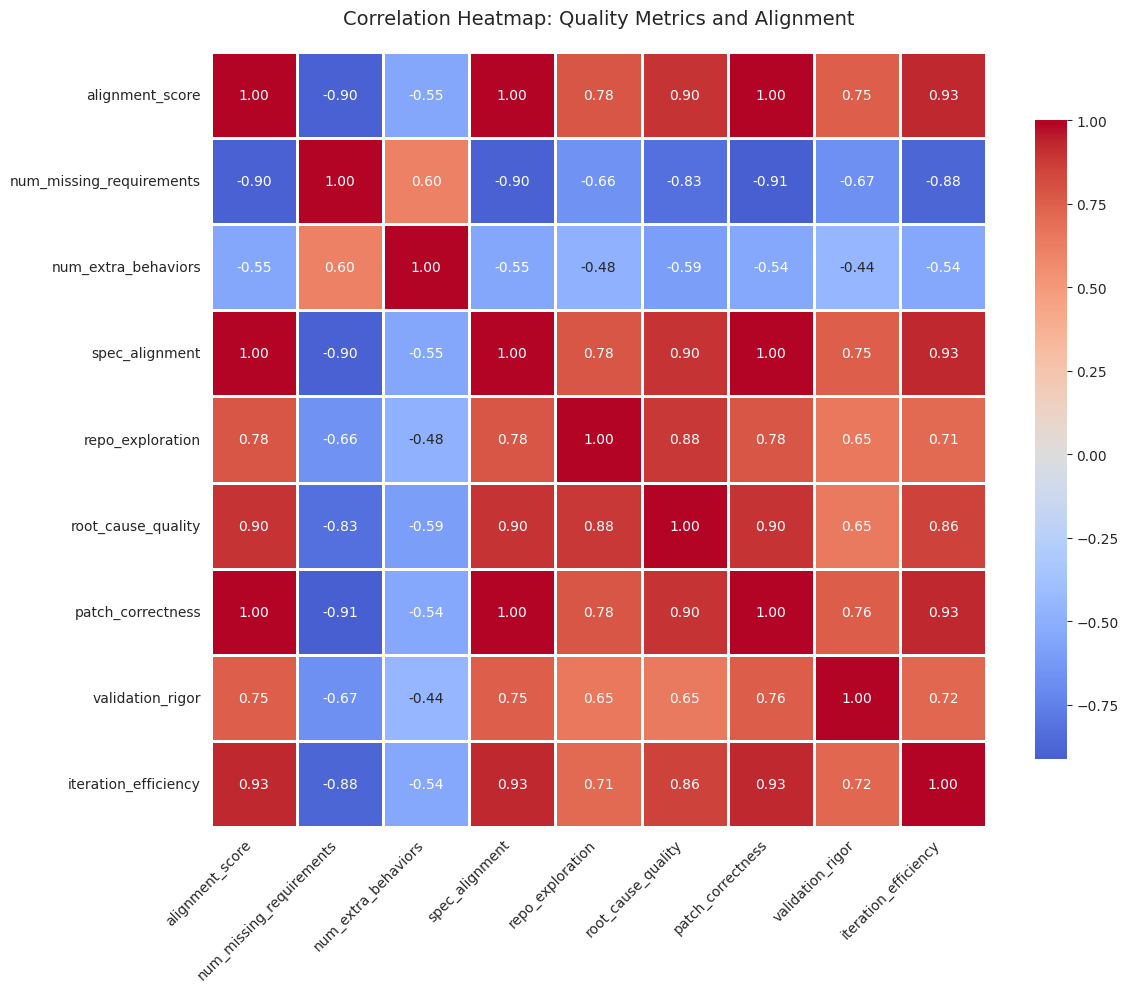

✓ Saved to correlation_heatmap.png


In [14]:
# Select numeric columns for correlation
numeric_cols = [
    'alignment_score', 'num_missing_requirements', 'num_extra_behaviors',
    'spec_alignment', 'repo_exploration', 'root_cause_quality',
    'patch_correctness', 'validation_rigor', 'iteration_efficiency'
]

# Calculate correlation matrix
corr_matrix = valid_df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap: Quality Metrics and Alignment', fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved to correlation_heatmap.png")

## 8. Deep Dive: Investigate Specific Instances

Pick an instance to examine in detail.

In [15]:
# Example: Look at the first resolved-but-wrong instance
if len(resolved_but_wrong) > 0:
    instance_id_to_examine = resolved_but_wrong.iloc[0]['instance_id']
else:
    # Fallback to any instance
    instance_id_to_examine = valid_df.iloc[0]['instance_id']

print(f"Examining instance: {instance_id_to_examine}")
print("="*80)

# Get the full result
full_result = next((r for r in results if r['instance_id'] == instance_id_to_examine), None)

if full_result:
    print(f"\nResolved (by test suite): {full_result['resolved']}")
    
    if 'judge_evaluation' in full_result:
        judge_eval = full_result['judge_evaluation']
        
        print(f"\nJudge Outcome: {judge_eval.get('outcome', {}).get('status')}")
        print(f"Alignment Score: {judge_eval.get('patch_alignment', {}).get('alignment_score')}/4")
        print(f"\nPrimary Failure:")
        pf = judge_eval.get('primary_failure', {})
        print(f"  Class: {pf.get('class')}")
        print(f"  Reason: {pf.get('reason_code')}")
        print(f"  Stage: {pf.get('stage')}")
        
        print(f"\nDiagnosis:")
        diagnosis = judge_eval.get('narrative', {}).get('one_paragraph_diagnosis', 'N/A')
        print(diagnosis)
        
        print(f"\nMissing Requirements:")
        missing = judge_eval.get('patch_alignment', {}).get('missing_requirements', [])
        for req in missing:
            print(f"  - {req}")
        
        print(f"\nExtra Behavior Changes:")
        extra = judge_eval.get('patch_alignment', {}).get('extra_behavior_changes', [])
        for change in extra:
            print(f"  - {change}")
else:
    print("Instance not found")

Examining instance: django__django-11999

Resolved (by test suite): True

Judge Outcome: wrong_fix
Alignment Score: 1/4

Primary Failure:
  Class: internal
  Reason: INT_FIX_STRATEGY_WRONG_LEVEL
  Stage: implementation

Diagnosis:
The agent repeatedly attempted to ensure user-defined get_FIELD_display methods would override Django's auto-generated ones, but failed due to misunderstanding the metaclass construction order. The auto-generated method is set before user-defined methods are added, so the override is not respected. The agent's patch does not solve the problem, and the key test fails, confirming the issue remains.

Missing Requirements:
  - User-defined get_FIELD_display is not respected; auto-generated method still overrides.

Extra Behavior Changes:


## 9. Export Summary Report

In [ ]:
# Create comprehensive summary
summary = {
    'total_instances': len(df),
    'valid_evaluations': len(valid_df),
    'errors': int(df['has_error'].sum()),
    'resolved_count': int((valid_df['resolved'] == True).sum()),
    'unresolved_count': int((valid_df['resolved'] == False).sum()),
    'mismatches': {
        'resolved_but_wrong_fix': len(resolved_but_wrong),
        'unresolved_but_true_pass': len(unresolved_but_correct),
        'total_mismatches': len(resolved_but_wrong) + len(unresolved_but_correct),
        'mismatch_rate': f"{100*(len(resolved_but_wrong) + len(unresolved_but_correct))/len(valid_df):.2f}%"
    },
    'outcome_distribution': valid_df['outcome_status'].value_counts().to_dict(),
    'average_scores': {
        'alignment_score': float(valid_df['alignment_score'].mean()),
        'spec_alignment': float(valid_df['spec_alignment'].mean()),
        'repo_exploration': float(valid_df['repo_exploration'].mean()),
        'root_cause_quality': float(valid_df['root_cause_quality'].mean()),
        'patch_correctness': float(valid_df['patch_correctness'].mean()),
        'validation_rigor': float(valid_df['validation_rigor'].mean()),
        'iteration_efficiency': float(valid_df['iteration_efficiency'].mean()),
    },
    'files_generated': [
        'resolved_but_wrong_fix.csv',
        'unresolved_but_true_pass.csv',
        'outcome_distribution_by_resolved.png',
        'alignment_score_distribution.png',
        'quality_scores_comparison.png',
        'failure_class_distribution.png',
        'accidental_pass_risk.png',
        'correlation_heatmap.png'
    ]
}

# Save summary
with open('analysis_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Analysis Summary:")
print(json.dumps(summary, indent=2))
print("\n✓ Saved to analysis_summary.json")

## 10. Summary

This notebook has:
1. ✅ Loaded and parsed evaluation results
2. ✅ Identified **resolved but wrong fix** instances (false positives)
3. ✅ Identified **unresolved but true pass** instances (false negatives)
4. ✅ Created comprehensive visualizations
5. ✅ Exported CSV files for mismatch instances
6. ✅ Generated analysis summary

### Key Outputs:
- `resolved_but_wrong_fix.csv` - Instances that passed tests but are actually wrong
- `unresolved_but_true_pass.csv` - Instances that failed tests but are actually correct
- Multiple PNG visualizations showing distributions and patterns
- `analysis_summary.json` - Comprehensive statistics

### Next Steps:
1. Review the mismatch instances manually
2. Investigate patterns in the visualizations
3. Consider improving test suites for high-risk instances
4. Use the quality scores to identify areas for agent improvement